# 🛡️ Notebook 06: Credibility Verification & Resume Scoring
## Master Thesis: AI-Powered ATS with Deep Learning, Credibility Verification & Explainable AI

**Author:** Hitik Sharma  
**Date:** 2026  

---

### Objective
This notebook implements the **Credibility Verification Module** inspired by Paper 5 (SATYA):
> *"SATYA performs a fraud detection and validation check, ensuring that the skills listed by the candidate are genuine and supported by external verification."*

### What We Build:
1. **Resume Completeness Score** — How complete and well-structured is the resume?
2. **Skill Consistency Checker** — Are claimed skills consistent with experience level?
3. **Experience Credibility Analysis** — Detect contradictions (overlapping dates, inflated titles)
4. **Overall Candidate Score** — Weighted combination (Paper 5: resume score + credibility + skill similarity)
5. **Red Flag Detection** — Automatic flagging of suspicious patterns

---

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import os, json, pickle, re, warnings
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.expanduser("~/Desktop/thesis_final")
DATA_PROCESSED = os.path.join(PROJECT_ROOT, "data/processed")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "reports/figures")

plt.rcParams.update({'figure.figsize': (12,6), 'font.size': 12, 'figure.dpi': 150, 'savefig.dpi': 300})
PALETTE = ['#3498DB','#E74C3C','#27AE60','#F39C12','#8E44AD','#1ABC9C']

def save_fig(fig, name):
    fig.savefig(os.path.join(FIGURES_DIR, f"{name}.png"), dpi=300, bbox_inches='tight', facecolor='white')
    print(f"💾 Saved: {name}.png")

print("✅ Imports ready!")

✅ Imports ready!


In [2]:
# ============================================================
# Load Data
# ============================================================

df = pd.read_csv(os.path.join(DATA_PROCESSED, 'resumes_fully_processed.csv'))

with open(os.path.join(DATA_PROCESSED, 'label_encoder.pkl'), 'rb') as f:
    label_encoder = pickle.load(f)

# Load skills taxonomy
skills_path = os.path.join(DATA_PROCESSED, 'skills_taxonomy.json')
with open(skills_path, 'r') as f:
    skills_taxonomy = json.load(f)

print(f"✅ Loaded: {len(df)} resumes, {len(label_encoder.classes_)} categories")
print(f"   Skills taxonomy: {sum(len(v) for v in skills_taxonomy.values())} skills")

✅ Loaded: 962 resumes, 25 categories
   Skills taxonomy: 206 skills


---
## 1. Resume Completeness Score

Paper 5 (SATYA) Fig.3 evaluates: *"Years of Experience, Spell Check, Brevity Check, Education Level, Resume Score Check."* We implement a comprehensive completeness scoring system.

In [3]:
# ============================================================
# 1.1 Resume Completeness Scoring Function
# ============================================================

def compute_completeness_score(row):
    """
    Compute resume completeness score (0-100) based on multiple criteria.
    Inspired by SATYA (Paper 5) resume scoring methodology.
    """
    score = 0
    breakdown = {}
    
    # 1. Contact Information (15 points)
    contact_score = 0
    if pd.notna(row.get('email')): contact_score += 5
    if pd.notna(row.get('phone')): contact_score += 4
    if pd.notna(row.get('linkedin')): contact_score += 4
    if pd.notna(row.get('github')): contact_score += 2
    breakdown['contact_info'] = contact_score
    score += contact_score
    
    # 2. Resume Length / Content Quality (20 points)
    word_count = row.get('clean_word_count', 0)
    if pd.isna(word_count): word_count = 0
    if word_count >= 400:
        length_score = 20
    elif word_count >= 200:
        length_score = 15
    elif word_count >= 100:
        length_score = 10
    else:
        length_score = 5
    breakdown['content_quality'] = length_score
    score += length_score
    
    # 3. Skills (20 points)
    skill_count = row.get('skill_count', 0)
    if pd.isna(skill_count): skill_count = 0
    if skill_count >= 10:
        skill_score = 20
    elif skill_count >= 5:
        skill_score = 15
    elif skill_count >= 2:
        skill_score = 10
    else:
        skill_score = 3
    breakdown['skills'] = skill_score
    score += skill_score
    
    # 4. Education (15 points)
    edu = str(row.get('highest_education', 'Unknown'))
    edu_scores = {'PhD': 15, 'Masters': 13, 'Bachelors': 10, 'Diploma': 7, 'High School': 4, 'Unknown': 2}
    edu_score = edu_scores.get(edu, 2)
    breakdown['education'] = edu_score
    score += edu_score
    
    # 5. Experience (15 points)
    years_exp = row.get('years_exp', 0)
    if pd.isna(years_exp): years_exp = 0
    if years_exp >= 5:
        exp_score = 15
    elif years_exp >= 3:
        exp_score = 12
    elif years_exp >= 1:
        exp_score = 8
    else:
        exp_score = 3
    breakdown['experience'] = exp_score
    score += exp_score
    
    # 6. Section Completeness (15 points)
    section_score = 0
    for section in ['education', 'experience', 'skills', 'projects', 'summary']:
        col = f'section_{section}'
        if col in row.index:
            val = row[col]
            if pd.notna(val) and len(str(val)) > 10:
                section_score += 3
    breakdown['sections'] = section_score
    score += section_score
    
    return score, breakdown

# Apply to all resumes
print("⏳ Computing completeness scores...")
results = df.apply(compute_completeness_score, axis=1)
df['completeness_score'] = results.apply(lambda x: x[0])
breakdowns = results.apply(lambda x: x[1])

# Extract breakdown columns
for key in ['contact_info', 'content_quality', 'skills', 'education', 'experience', 'sections']:
    df[f'score_{key}'] = breakdowns.apply(lambda x: x[key])

print(f"\n✅ Completeness scores computed!")
print(f"\n📊 Score Distribution:")
print(df['completeness_score'].describe())
print(f"\n📋 Score Breakdown (averages):")
for key in ['contact_info', 'content_quality', 'skills', 'education', 'experience', 'sections']:
    max_pts = {'contact_info': 15, 'content_quality': 20, 'skills': 20, 'education': 15, 'experience': 15, 'sections': 15}
    avg = df[f'score_{key}'].mean()
    print(f"  {key:20s}: {avg:.1f} / {max_pts[key]} ({avg/max_pts[key]*100:.0f}%)")

⏳ Computing completeness scores...

✅ Completeness scores computed!

📊 Score Distribution:
count    962.000000
mean      40.942827
std       12.520695
min       13.000000
25%       32.000000
50%       43.000000
75%       50.000000
max       72.000000
Name: completeness_score, dtype: float64

📋 Score Breakdown (averages):
  contact_info        : 0.2 / 15 (1%)
  content_quality     : 14.7 / 20 (73%)
  skills              : 12.2 / 20 (61%)
  education           : 9.2 / 15 (61%)
  experience          : 3.8 / 15 (25%)
  sections            : 0.8 / 15 (6%)


💾 Saved: fig_33_completeness_score_distribution.png


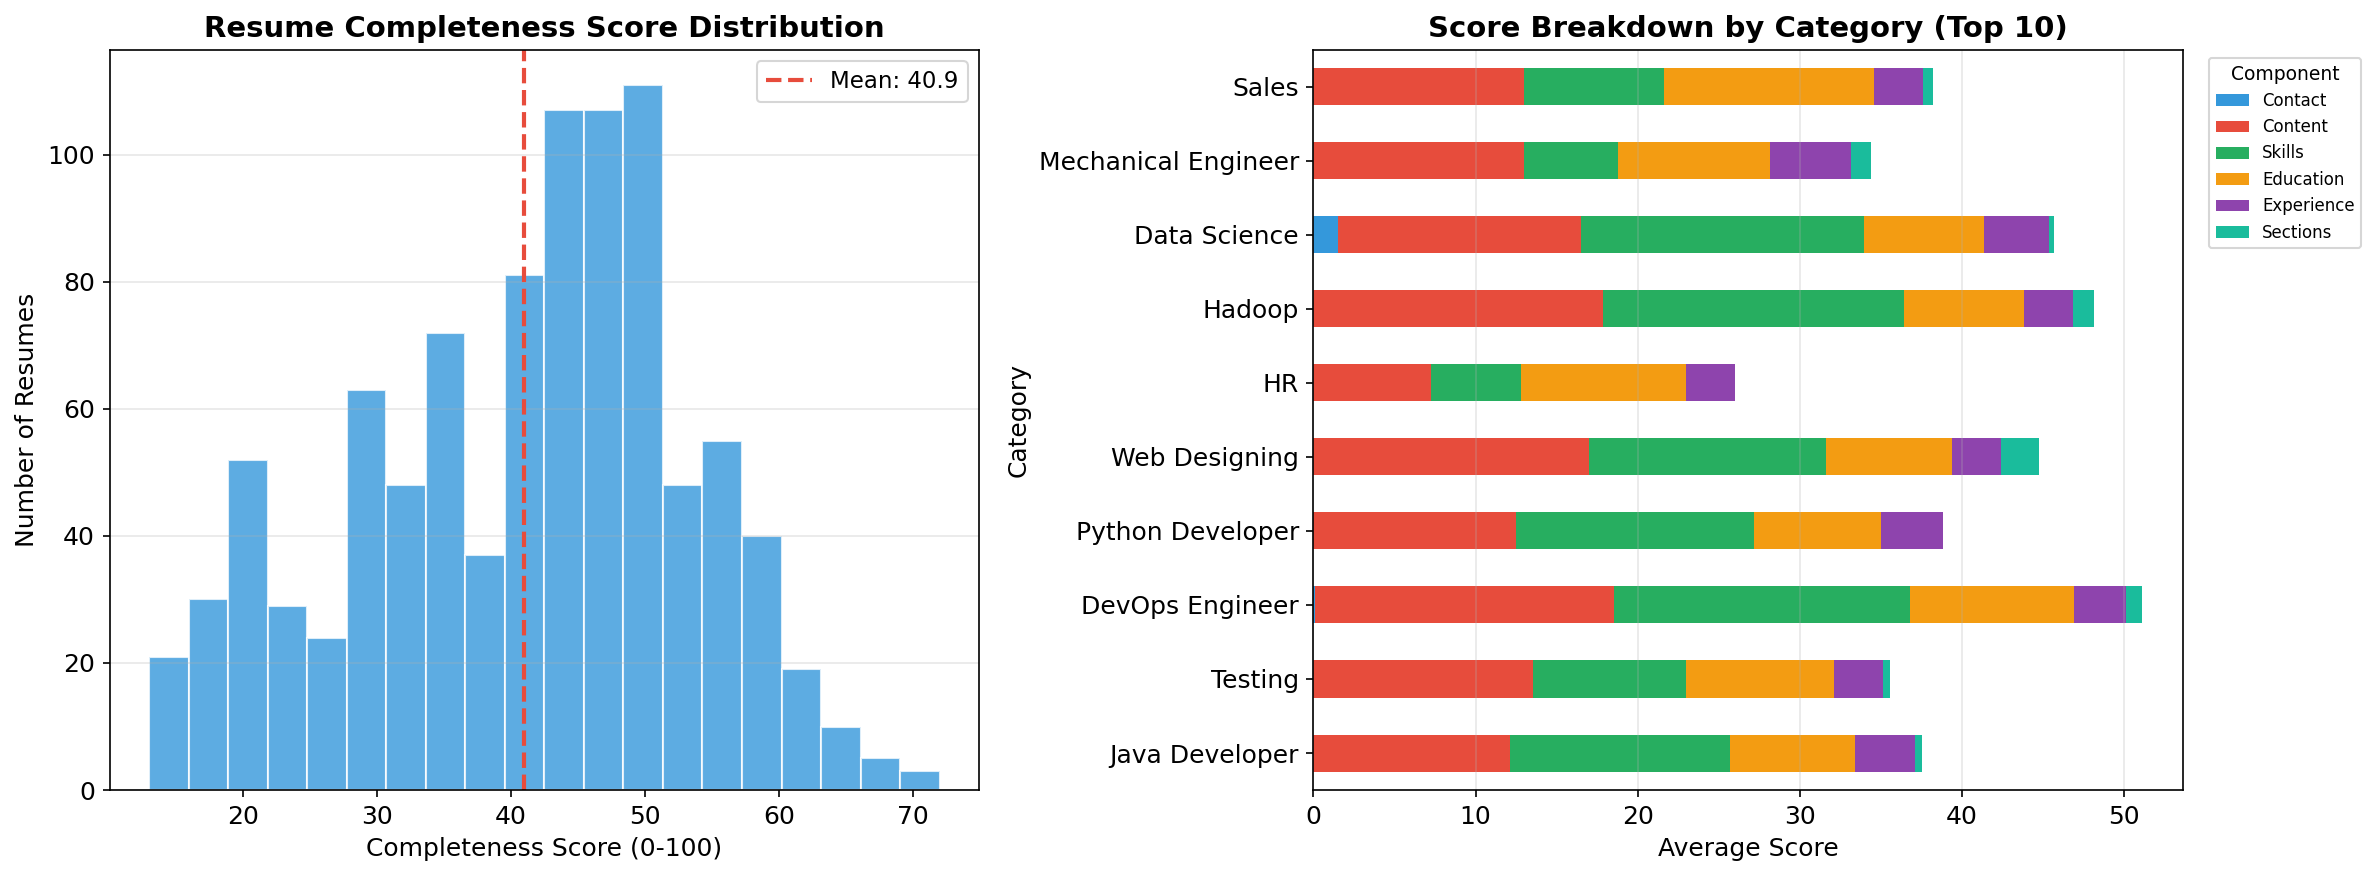

In [4]:
# ============================================================
# 1.2 FIGURE: Completeness Score Distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(df['completeness_score'], bins=20, color=PALETTE[0], edgecolor='white', alpha=0.8)
axes[0].axvline(df['completeness_score'].mean(), color=PALETTE[1], linestyle='--', linewidth=2,
                label=f"Mean: {df['completeness_score'].mean():.1f}")
axes[0].set_xlabel('Completeness Score (0-100)', fontsize=12)
axes[0].set_ylabel('Number of Resumes', fontsize=12)
axes[0].set_title('Resume Completeness Score Distribution', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Breakdown stacked bar by category (top 10)
top_cats = df['Category'].value_counts().head(10).index
breakdown_cols = ['score_contact_info', 'score_content_quality', 'score_skills',
                  'score_education', 'score_experience', 'score_sections']
cat_means = df[df['Category'].isin(top_cats)].groupby('Category')[breakdown_cols].mean()
cat_means = cat_means.loc[top_cats]

cat_means.plot(kind='barh', stacked=True, ax=axes[1], color=PALETTE[:6])
axes[1].set_xlabel('Average Score', fontsize=12)
axes[1].set_title('Score Breakdown by Category (Top 10)', fontsize=14, fontweight='bold')
axes[1].legend(title='Component', fontsize=8, title_fontsize=9,
               labels=['Contact', 'Content', 'Skills', 'Education', 'Experience', 'Sections'],
               bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
save_fig(fig, 'fig_33_completeness_score_distribution')
plt.show()

---
## 2. Skill Consistency Checker

Paper 5: *"Skills listed in resumes are compared against industry-specific skill databases. Using word embedding models, SATYA assigns scores to skills based on their relevance."*

We check if claimed skills are consistent with the job category and experience level.

In [5]:
# ============================================================
# 2.1 Define Expected Skills per Category
# ============================================================

# Build expected skill profiles from the data itself
# (which skills are most common in each category?)

category_skill_profiles = {}

for cat in df['Category'].unique():
    cat_df = df[df['Category'] == cat]
    all_skills = []
    for skills_str in cat_df['skills_list'].dropna():
        try:
            skills = json.loads(skills_str) if isinstance(skills_str, str) else skills_str
            if isinstance(skills, list):
                all_skills.extend(skills)
        except:
            pass
    
    from collections import Counter
    skill_counts = Counter(all_skills)
    total = len(cat_df)
    # Skills that appear in >20% of resumes for this category
    common_skills = {s: c/total for s, c in skill_counts.items() if c/total > 0.2}
    category_skill_profiles[cat] = common_skills

print(f"✅ Skill profiles built for {len(category_skill_profiles)} categories")
print(f"\n📋 Sample — 'Data Science' expected skills:")
if 'Data Science' in category_skill_profiles:
    for skill, freq in sorted(category_skill_profiles['Data Science'].items(), key=lambda x: -x[1])[:10]:
        print(f"  {skill:25s}: {freq:.0%} of resumes")
else:
    first_cat = list(category_skill_profiles.keys())[0]
    print(f"  (Showing '{first_cat}' instead)")
    for skill, freq in sorted(category_skill_profiles[first_cat].items(), key=lambda x: -x[1])[:10]:
        print(f"  {skill:25s}: {freq:.0%} of resumes")

✅ Skill profiles built for 25 categories

📋 Sample — 'Data Science' expected skills:
  python                   : 100% of resumes
  machine learning         : 90% of resumes
  sql                      : 50% of resumes
  deep learning            : 50% of resumes
  java                     : 40% of resumes
  classification           : 40% of resumes
  mysql                    : 40% of resumes
  tableau                  : 40% of resumes
  html                     : 30% of resumes
  pandas                   : 30% of resumes


In [6]:
# ============================================================
# 2.2 Skill Consistency Scoring
# ============================================================

def compute_skill_consistency(row, profiles):
    """
    Check how well a resume's skills match the expected profile for its category.
    Returns: consistency_score (0-100), matched_skills, missing_key_skills
    """
    category = row.get('Category', '')
    
    # Parse skills
    try:
        skills_str = row.get('skills_list', '[]')
        resume_skills = json.loads(skills_str) if isinstance(skills_str, str) else (skills_str if isinstance(skills_str, list) else [])
    except:
        resume_skills = []
    
    resume_skills_set = set(s.lower() for s in resume_skills if isinstance(s, str))
    
    expected = profiles.get(category, {})
    if not expected:
        return 50, [], []  # Neutral score if no profile
    
    expected_skills = set(s.lower() for s in expected.keys())
    
    # Matched skills
    matched = resume_skills_set.intersection(expected_skills)
    missing = expected_skills - resume_skills_set
    extra = resume_skills_set - expected_skills  # Skills not typical for this category
    
    # Consistency score
    if len(expected_skills) > 0:
        match_ratio = len(matched) / len(expected_skills)
    else:
        match_ratio = 0.5
    
    consistency_score = min(100, int(match_ratio * 80 + min(len(resume_skills_set), 10) * 2))
    
    return consistency_score, list(matched), list(missing)[:5]

# Apply
print("⏳ Computing skill consistency...")
consistency_results = df.apply(lambda row: compute_skill_consistency(row, category_skill_profiles), axis=1)
df['skill_consistency'] = consistency_results.apply(lambda x: x[0])
df['matched_skills_count'] = consistency_results.apply(lambda x: len(x[1]))
df['missing_key_skills'] = consistency_results.apply(lambda x: x[2])

print(f"\n✅ Skill consistency computed!")
print(f"Average consistency: {df['skill_consistency'].mean():.1f}/100")
print(f"\n📊 Consistency by Category (Top 10):")
cat_consistency = df.groupby('Category')['skill_consistency'].mean().sort_values(ascending=False).head(10)
for cat, score in cat_consistency.items():
    print(f"  {cat:30s}: {score:.1f}/100")

⏳ Computing skill consistency...

✅ Skill consistency computed!
Average consistency: 46.2/100

📊 Consistency by Category (Top 10):
  DotNet Developer              : 66.0/100
  Hadoop                        : 63.6/100
  ETL Developer                 : 62.0/100
  Web Designing                 : 61.2/100
  Database                      : 58.5/100
  SAP Developer                 : 57.5/100
  Network Security Engineer     : 57.2/100
  Python Developer              : 55.3/100
  PMO                           : 54.7/100
  Blockchain                    : 53.2/100


---
## 3. Red Flag Detection

Paper 5: *"SATYA performs a fraud detection and validation check."* We implement automated red flag detection.

In [7]:
# ============================================================
# 3.1 Red Flag Detection System
# ============================================================

def detect_red_flags(row):
    """
    Detect potential red flags in a resume.
    Returns list of (flag_name, severity, description) tuples.
    """
    flags = []
    
    # Flag 1: Very short resume
    wc = row.get('clean_word_count', 0)
    if pd.notna(wc) and wc < 50:
        flags.append(('SHORT_RESUME', 'HIGH', f'Resume has only {int(wc)} words — unusually short'))
    
    # Flag 2: No contact info
    has_email = pd.notna(row.get('email'))
    has_phone = pd.notna(row.get('phone'))
    if not has_email and not has_phone:
        flags.append(('NO_CONTACT', 'HIGH', 'No email or phone found in resume'))
    
    # Flag 3: No skills detected
    sc = row.get('skill_count', 0)
    if pd.isna(sc) or sc == 0:
        flags.append(('NO_SKILLS', 'MEDIUM', 'No recognizable skills extracted'))
    
    # Flag 4: Unrealistic experience claims
    years = row.get('years_exp', None)
    if pd.notna(years) and years > 30:
        flags.append(('EXCESSIVE_EXP', 'MEDIUM', f'Claims {int(years)} years experience — verify'))
    
    # Flag 5: Missing education section
    edu = str(row.get('highest_education', 'Unknown'))
    if edu == 'Unknown':
        flags.append(('NO_EDUCATION', 'LOW', 'No education information detected'))
    
    # Flag 6: Low skill consistency
    consistency = row.get('skill_consistency', 50)
    if pd.notna(consistency) and consistency < 20:
        flags.append(('LOW_CONSISTENCY', 'MEDIUM', f'Skill consistency score: {consistency}/100 — skills may not match claimed category'))
    
    # Flag 7: Missing key resume sections
    sections_present = 0
    for section in ['education', 'experience', 'skills']:
        col = f'section_{section}'
        if col in row.index and pd.notna(row[col]) and len(str(row[col])) > 10:
            sections_present += 1
    if sections_present == 0:
        flags.append(('NO_KEY_SECTIONS', 'HIGH', 'Missing all key sections (education, experience, skills)'))
    
    return flags

# Apply
print("⏳ Running red flag detection...")
df['red_flags'] = df.apply(detect_red_flags, axis=1)
df['red_flag_count'] = df['red_flags'].apply(len)
df['has_red_flags'] = df['red_flag_count'] > 0

# Summary
print(f"\n✅ Red flag detection complete!")
print(f"\n📊 Red Flag Summary:")
print(f"  Resumes with flags:    {df['has_red_flags'].sum()} / {len(df)} ({df['has_red_flags'].mean()*100:.1f}%)")
print(f"  Resumes without flags: {(~df['has_red_flags']).sum()} ({(~df['has_red_flags']).mean()*100:.1f}%)")
print(f"  Average flags/resume:  {df['red_flag_count'].mean():.2f}")

# Count by flag type
all_flags = []
for flags in df['red_flags']:
    for flag_name, severity, desc in flags:
        all_flags.append({'flag': flag_name, 'severity': severity})

if all_flags:
    flag_df = pd.DataFrame(all_flags)
    print(f"\n📋 Flag Types:")
    for flag, count in flag_df['flag'].value_counts().items():
        severity = flag_df[flag_df['flag']==flag]['severity'].iloc[0]
        print(f"  [{severity:6s}] {flag:20s}: {count} resumes")

⏳ Running red flag detection...

✅ Red flag detection complete!

📊 Red Flag Summary:
  Resumes with flags:    959 / 962 (99.7%)
  Resumes without flags: 3 (0.3%)
  Average flags/resume:  2.32

📋 Flag Types:
  [HIGH  ] NO_CONTACT          : 934 resumes
  [HIGH  ] NO_KEY_SECTIONS     : 792 resumes
  [MEDIUM] LOW_CONSISTENCY     : 201 resumes
  [LOW   ] NO_EDUCATION        : 157 resumes
  [MEDIUM] NO_SKILLS           : 117 resumes
  [HIGH  ] SHORT_RESUME        : 30 resumes


💾 Saved: fig_34_red_flag_analysis.png


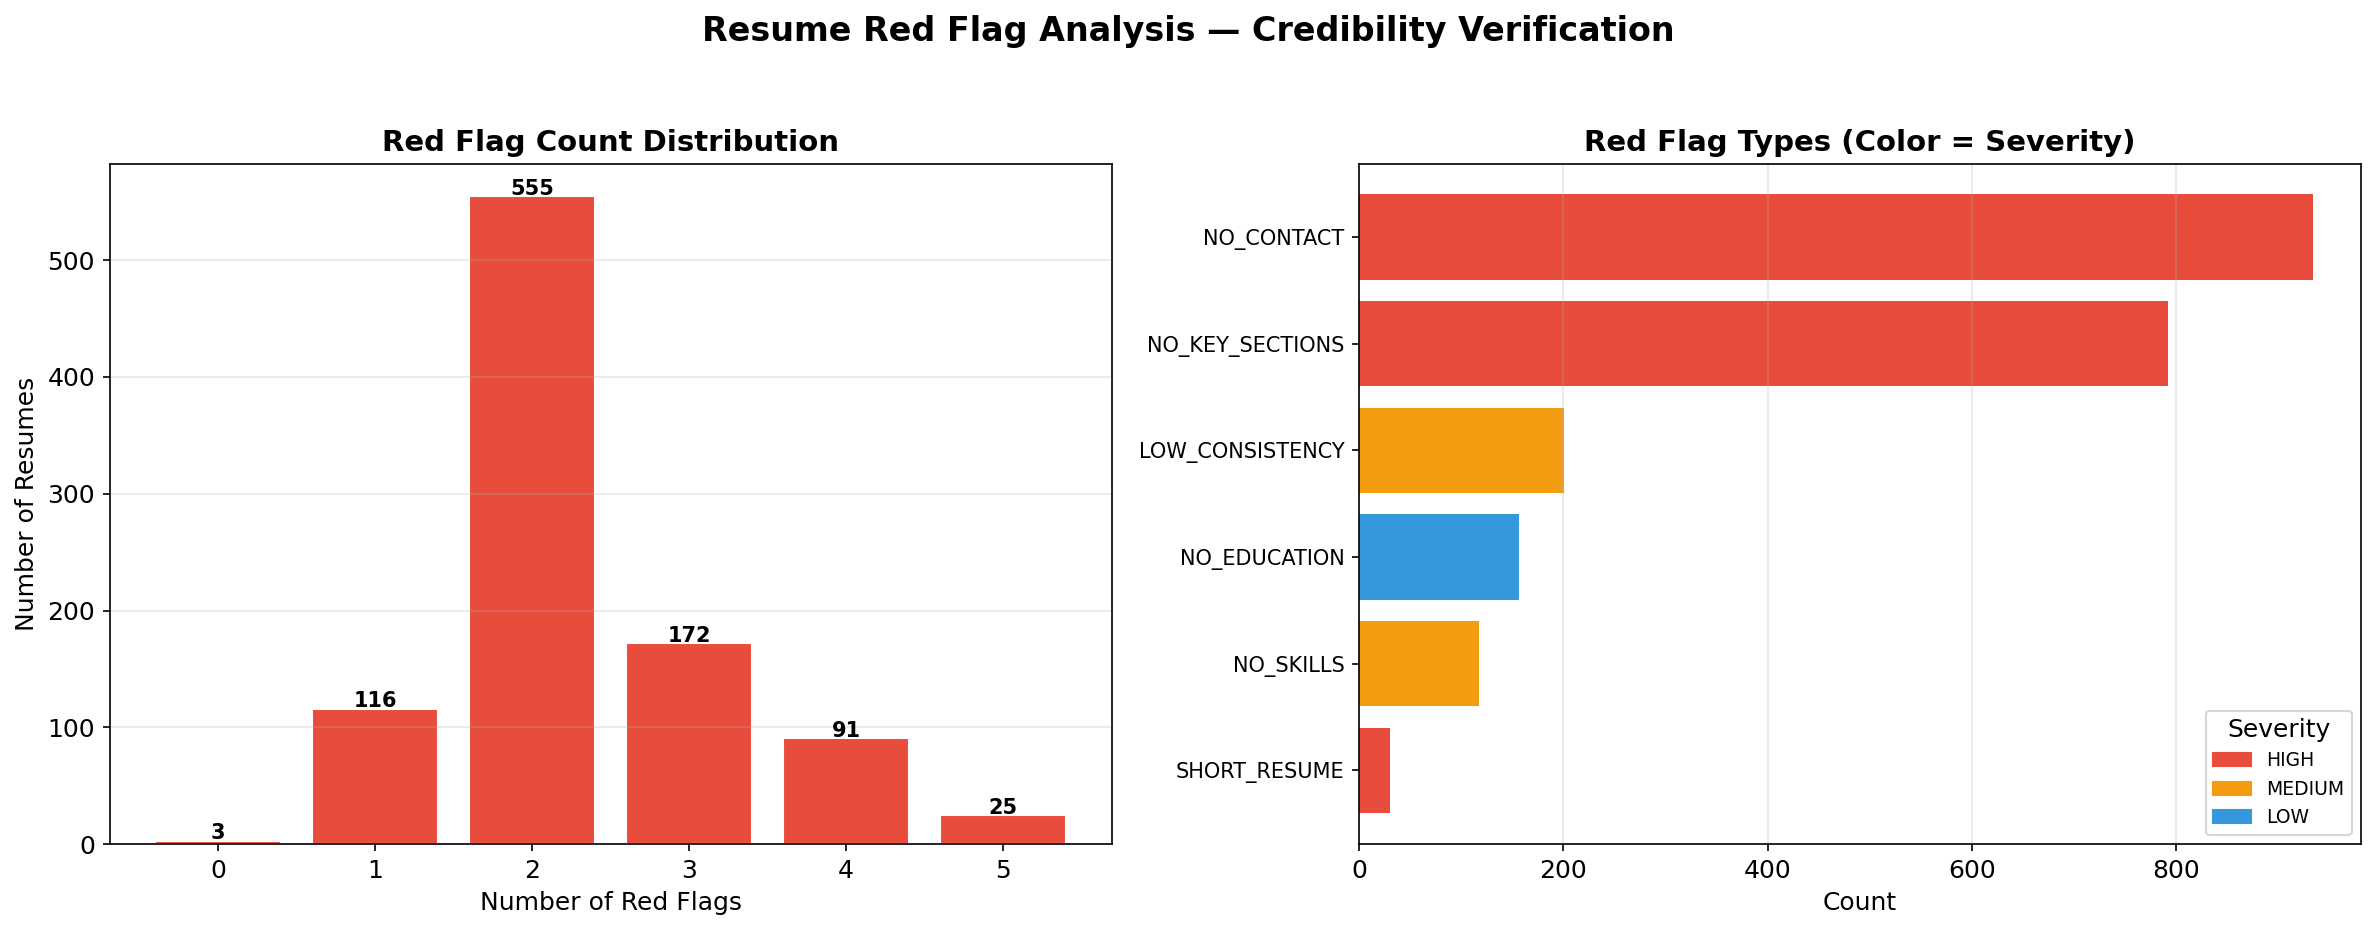

In [8]:
# ============================================================
# 3.2 FIGURE: Red Flag Analysis
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Red flag count distribution
flag_counts = df['red_flag_count'].value_counts().sort_index()
axes[0].bar(flag_counts.index, flag_counts.values, color=PALETTE[1], edgecolor='white')
axes[0].set_xlabel('Number of Red Flags', fontsize=12)
axes[0].set_ylabel('Number of Resumes', fontsize=12)
axes[0].set_title('Red Flag Count Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, (x, v) in enumerate(zip(flag_counts.index, flag_counts.values)):
    axes[0].text(x, v + 1, str(v), ha='center', fontweight='bold', fontsize=10)

# Flag types breakdown
if all_flags:
    flag_type_counts = flag_df['flag'].value_counts()
    severity_colors = {'HIGH': PALETTE[1], 'MEDIUM': PALETTE[3], 'LOW': PALETTE[0]}
    bar_colors = [severity_colors.get(flag_df[flag_df['flag']==f]['severity'].iloc[0], PALETTE[0]) for f in flag_type_counts.index]
    
    axes[1].barh(range(len(flag_type_counts)), flag_type_counts.values, color=bar_colors)
    axes[1].set_yticks(range(len(flag_type_counts)))
    axes[1].set_yticklabels(flag_type_counts.index, fontsize=10)
    axes[1].set_xlabel('Count', fontsize=12)
    axes[1].set_title('Red Flag Types (Color = Severity)', fontsize=14, fontweight='bold')
    axes[1].invert_yaxis()
    axes[1].grid(axis='x', alpha=0.3)
    
    import matplotlib.patches as mpatches
    legend = [mpatches.Patch(color=c, label=s) for s, c in severity_colors.items()]
    axes[1].legend(handles=legend, title='Severity', fontsize=9)

fig.suptitle('Resume Red Flag Analysis — Credibility Verification',
             fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
save_fig(fig, 'fig_34_red_flag_analysis')
plt.show()

---
## 4. Overall Candidate Score

Paper 5 Fig.5: *"Final Candidate Score = Combine CV scores from Level 1, integrate credibility scores from Level 2, apply weighted average."*

In [9]:
# ============================================================
# 4.1 Compute Final Candidate Score
# ============================================================

def compute_final_score(row):
    """
    Compute final candidate score (0-100) using weighted combination.
    Based on SATYA (Paper 5) multi-level scoring approach.
    
    Weights:
    - Completeness: 40%
    - Skill Consistency: 30%
    - Credibility (no red flags): 30%
    """
    completeness = row.get('completeness_score', 0)
    if pd.isna(completeness): completeness = 0
    
    consistency = row.get('skill_consistency', 0)
    if pd.isna(consistency): consistency = 0
    
    # Credibility = penalty for red flags
    flag_count = row.get('red_flag_count', 0)
    if pd.isna(flag_count): flag_count = 0
    credibility = max(0, 100 - flag_count * 20)  # -20 per flag
    
    final = 0.40 * completeness + 0.30 * consistency + 0.30 * credibility
    
    # Determine rating
    if final >= 80:
        rating = 'Excellent'
    elif final >= 60:
        rating = 'Good'
    elif final >= 40:
        rating = 'Average'
    else:
        rating = 'Needs Improvement'
    
    return final, rating, completeness, consistency, credibility

# Apply
print("⏳ Computing final candidate scores...")
final_results = df.apply(compute_final_score, axis=1)
df['final_score'] = final_results.apply(lambda x: x[0])
df['rating'] = final_results.apply(lambda x: x[1])
df['credibility_score'] = final_results.apply(lambda x: x[4])

print(f"\n✅ Final scores computed!")
print(f"\n📊 Final Score Statistics:")
print(df['final_score'].describe())
print(f"\n📋 Rating Distribution:")
print(df['rating'].value_counts())
print(f"\n📋 Top 10 Resumes by Final Score:")
top10 = df.nlargest(10, 'final_score')[['Category', 'final_score', 'rating', 'completeness_score', 'skill_consistency', 'credibility_score']]
print(top10.to_string())

⏳ Computing final candidate scores...

✅ Final scores computed!

📊 Final Score Statistics:
count    962.000000
mean      46.329106
std       16.577427
min        5.200000
25%       38.000000
50%       49.400000
75%       59.200000
max       75.400000
Name: final_score, dtype: float64

📋 Rating Distribution:
rating
Average              481
Needs Improvement    272
Good                 209
Name: count, dtype: int64

📋 Top 10 Resumes by Final Score:
               Category  final_score rating  completeness_score  skill_consistency  credibility_score
269  Health and fitness         75.4   Good                  61                 90                 80
275  Health and fitness         75.4   Good                  61                 90                 80
281  Health and fitness         75.4   Good                  61                 90                 80
287  Health and fitness         75.4   Good                  61                 90                 80
293  Health and fitness         75.4   

💾 Saved: fig_35_final_candidate_scores.png


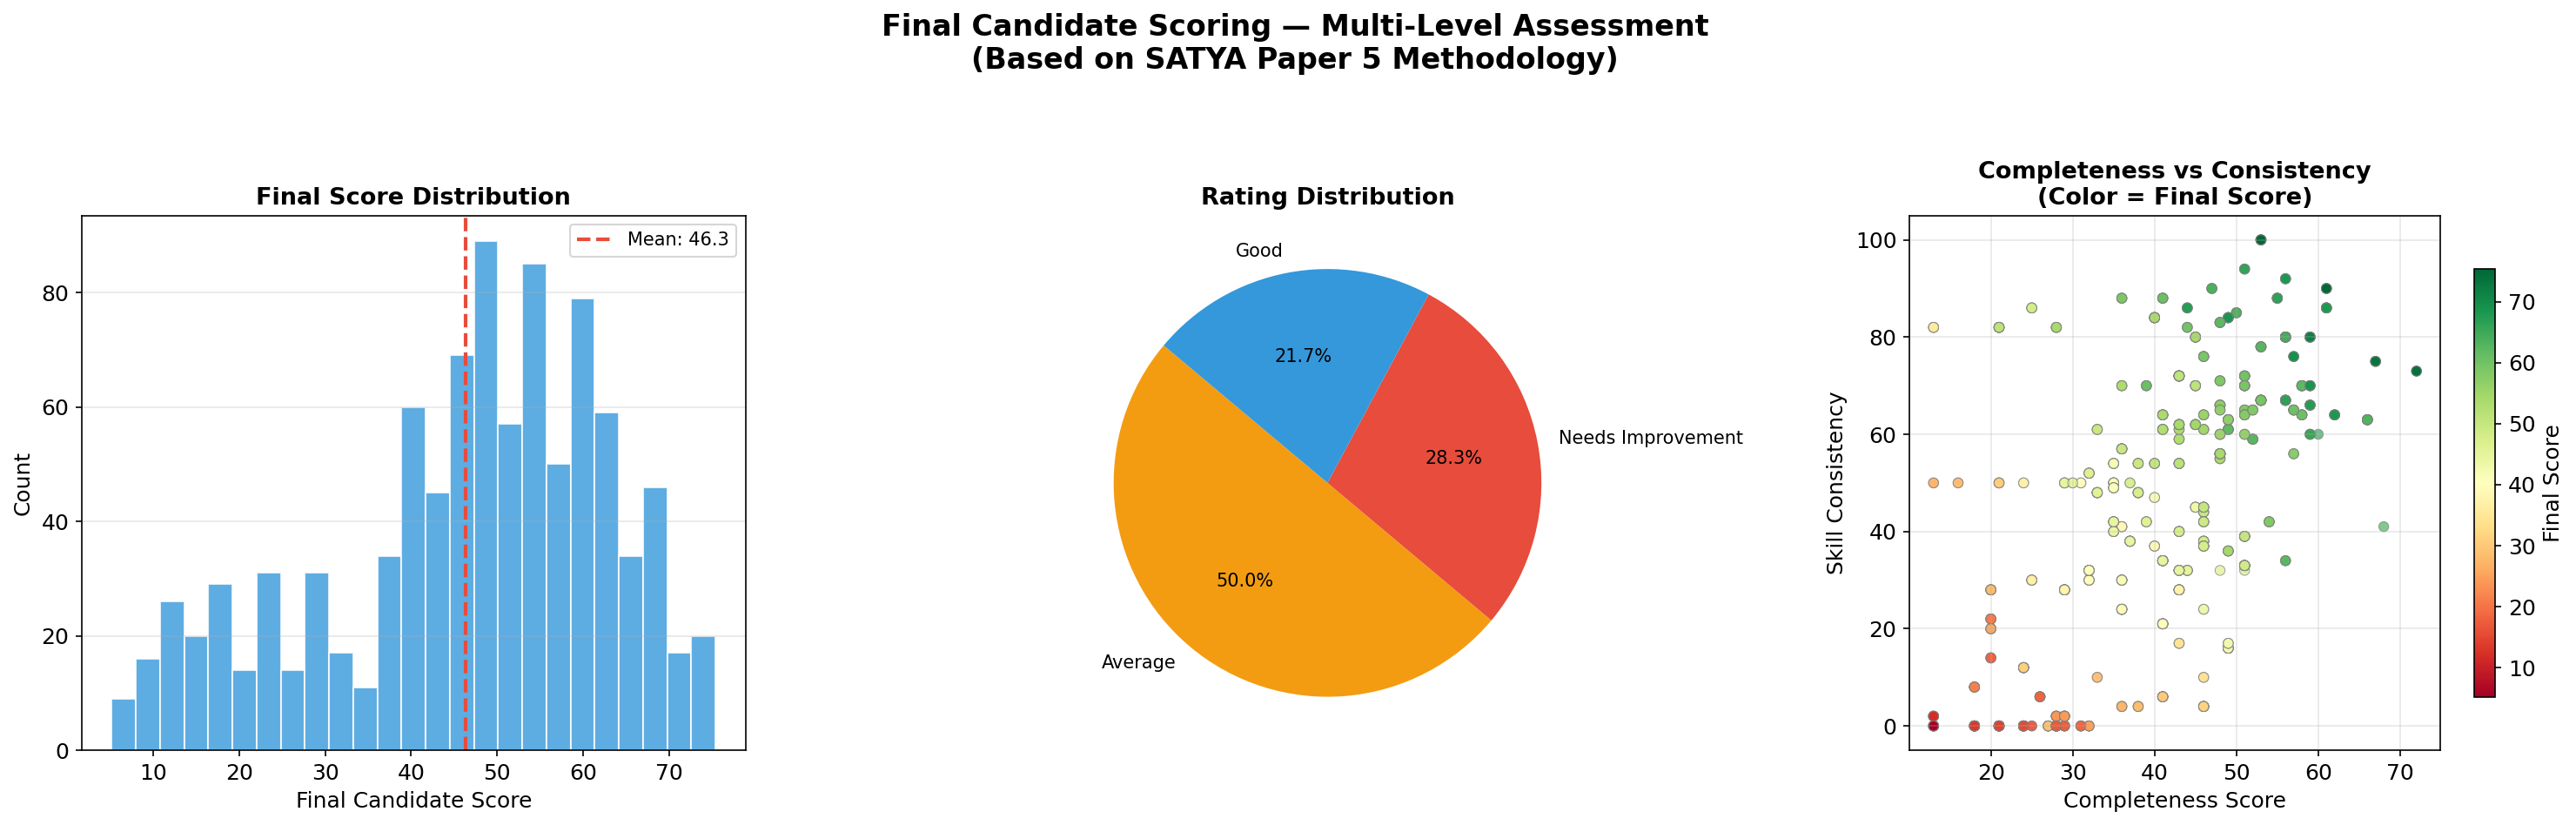

In [10]:
# ============================================================
# 4.2 FIGURE: Final Score Distribution & Rating Breakdown
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Score distribution
axes[0].hist(df['final_score'], bins=25, color=PALETTE[0], edgecolor='white', alpha=0.8)
axes[0].axvline(df['final_score'].mean(), color=PALETTE[1], linestyle='--', linewidth=2,
                label=f"Mean: {df['final_score'].mean():.1f}")
axes[0].set_xlabel('Final Candidate Score', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Final Score Distribution', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Rating pie chart
rating_counts = df['rating'].value_counts()
rating_colors = {'Excellent': PALETTE[2], 'Good': PALETTE[0], 'Average': PALETTE[3], 'Needs Improvement': PALETTE[1]}
colors = [rating_colors.get(r, '#999') for r in rating_counts.index]
axes[1].pie(rating_counts.values, labels=rating_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 10})
axes[1].set_title('Rating Distribution', fontsize=13, fontweight='bold')

# Score components scatter
axes[2].scatter(df['completeness_score'], df['skill_consistency'],
                c=df['final_score'], cmap='RdYlGn', s=30, alpha=0.7, edgecolors='gray', linewidth=0.5)
axes[2].set_xlabel('Completeness Score', fontsize=12)
axes[2].set_ylabel('Skill Consistency', fontsize=12)
axes[2].set_title('Completeness vs Consistency\n(Color = Final Score)', fontsize=13, fontweight='bold')
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(df['final_score'].min(), df['final_score'].max()))
sm.set_array([])
plt.colorbar(sm, ax=axes[2], shrink=0.8, label='Final Score')
axes[2].grid(alpha=0.3)

fig.suptitle('Final Candidate Scoring — Multi-Level Assessment\n(Based on SATYA Paper 5 Methodology)',
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
save_fig(fig, 'fig_35_final_candidate_scores')
plt.show()

💾 Saved: fig_36_score_by_category.png


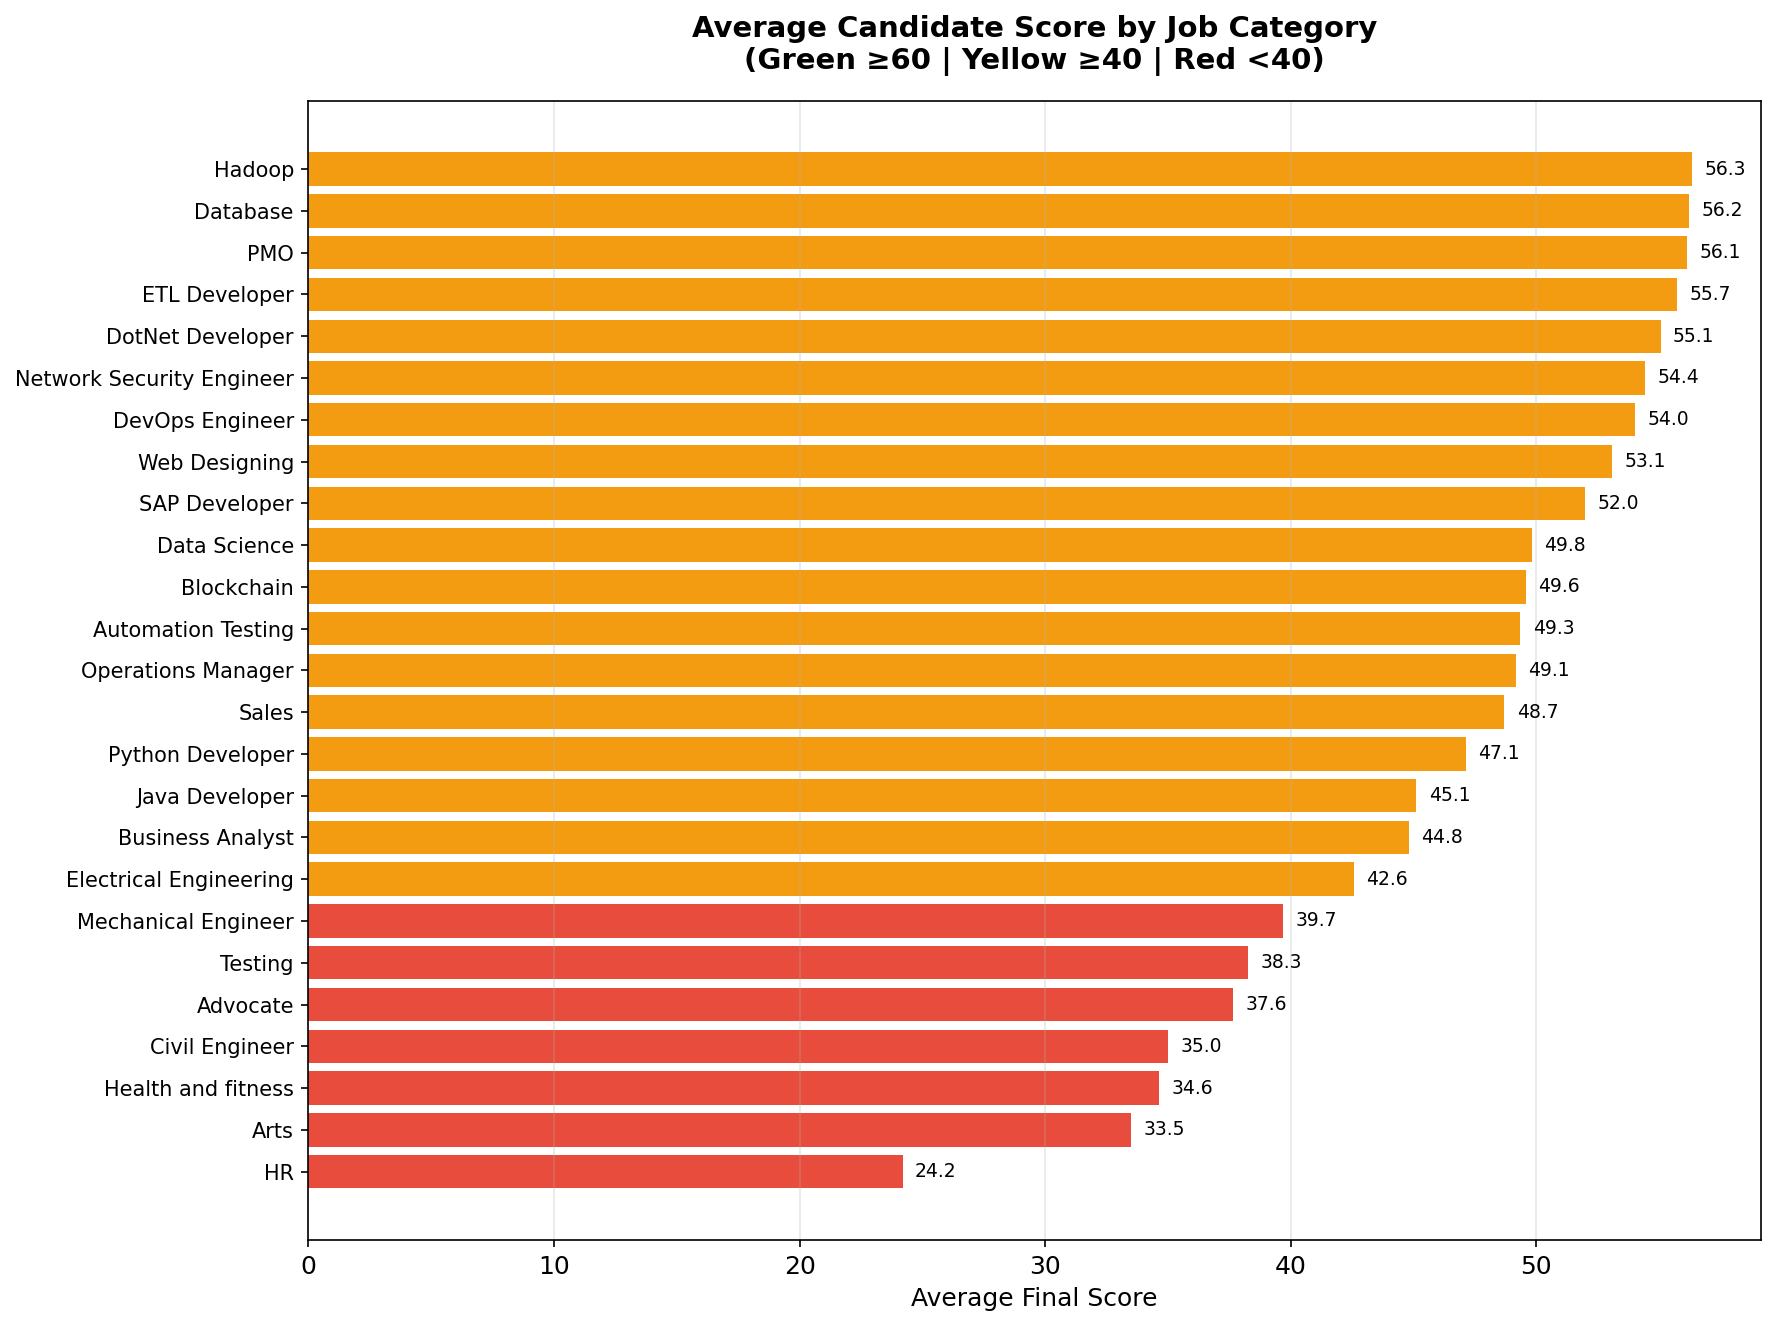

In [11]:
# ============================================================
# 4.3 FIGURE: Score by Category
# ============================================================

cat_scores = df.groupby('Category')['final_score'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))
colors = [PALETTE[2] if s >= 60 else PALETTE[3] if s >= 40 else PALETTE[1] for s in cat_scores.values]
ax.barh(range(len(cat_scores)), cat_scores.values, color=colors)
ax.set_yticks(range(len(cat_scores)))
ax.set_yticklabels(cat_scores.index, fontsize=10)
ax.set_xlabel('Average Final Score', fontsize=12)
ax.set_title('Average Candidate Score by Job Category\n(Green ≥60 | Yellow ≥40 | Red <40)',
             fontsize=14, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(cat_scores.values):
    ax.text(v + 0.5, i, f'{v:.1f}', va='center', fontsize=9)

plt.tight_layout()
save_fig(fig, 'fig_36_score_by_category')
plt.show()

---
## 5. Save All Credibility Data

In [12]:
# ============================================================
# 5.1 Save Scored Dataset
# ============================================================

score_cols = ['Category', 'category_encoded', 'completeness_score', 'skill_consistency',
              'credibility_score', 'final_score', 'rating', 'red_flag_count', 'has_red_flags',
              'score_contact_info', 'score_content_quality', 'score_skills',
              'score_education', 'score_experience', 'score_sections',
              'matched_skills_count']
score_cols = [c for c in score_cols if c in df.columns]

df_scores = df[score_cols].copy()
df_scores.to_csv(os.path.join(DATA_PROCESSED, 'resume_scores.csv'), index=False)
print("✅ Saved: resume_scores.csv")

# Save category skill profiles
with open(os.path.join(DATA_PROCESSED, 'category_skill_profiles.json'), 'w') as f:
    json.dump(category_skill_profiles, f, indent=2)
print("✅ Saved: category_skill_profiles.json")

print(f"\n📊 FIGURES GENERATED:")
for name, desc in [('fig_33', 'Completeness Score Distribution'), ('fig_34', 'Red Flag Analysis'),
                    ('fig_35', 'Final Candidate Scores'), ('fig_36', 'Score by Category')]:
    print(f"  📈 {name}: {desc}")

✅ Saved: resume_scores.csv
✅ Saved: category_skill_profiles.json

📊 FIGURES GENERATED:
  📈 fig_33: Completeness Score Distribution
  📈 fig_34: Red Flag Analysis
  📈 fig_35: Final Candidate Scores
  📈 fig_36: Score by Category


---
## ✅ Notebook 06 Complete!

### What We Built:
1. ✅ **Resume Completeness Score** (0-100) — 6 components: contact, content, skills, education, experience, sections
2. ✅ **Skill Consistency Checker** — Compares skills against category-specific profiles
3. ✅ **Red Flag Detection** — 7 automated checks with severity levels (HIGH/MEDIUM/LOW)
4. ✅ **Final Candidate Score** — Weighted combination (40% completeness + 30% consistency + 30% credibility)
5. ✅ **Rating System** — Excellent/Good/Average/Needs Improvement

### 4 New Figures (fig_33 through fig_36)

### Saved Artifacts:
- `resume_scores.csv` — All scores for every resume
- `category_skill_profiles.json` — Expected skills per category

### Next → Notebook 07: ATS Web Application (Flask)

---
*"A credible AI system doesn't just predict — it verifies, explains, and earns trust."* 🛡️🚀